# EN3160 L03 — Correlation vs Convolution, cell by cell
Run each cell in order. Each one isolates one piece of the idea before moving to the next.

## Setup
Imports used throughout the notebook.

In [10]:
import cv2 as cv
import numpy as np
from scipy import signal
from matplotlib import pyplot as plt


## 1. 1D toy example
Easiest place to *see* the flip — no 2D geometry to get confused by.

`h = [1, 0, -1]` is asymmetric (not equal to its own reverse), so correlation and convolution will genuinely differ.

In [11]:
x = np.array([1, 2, 3, 4, 5])
h = np.array([1, 0, -1])   # asymmetric kernel

print("signal x:", x)
print("kernel h:", h)


signal x: [1 2 3 4 5]
kernel h: [ 1  0 -1]


### Correlation (no flip) vs convolution (flips h first)

In [12]:
corr_result = np.correlate(x, h, mode='same')  # correlation: no flip
conv_result = np.convolve(x, h, mode='same')     # convolution: h flipped automatically

print("correlation:", corr_result)
print("convolution:", conv_result)


correlation: [-2 -2 -2 -2  4]
convolution: [ 2  2  2  2 -4]


### Check the equivalence yourself
Convolving with `h` should be identical to correlating with `h` reversed.

In [13]:
h_flipped = h[::-1]
print("h flipped:", h_flipped)

check = np.correlate(x, h_flipped, mode='same')
print("correlate(x, h_flipped):", check)
print("matches convolution result:", np.array_equal(check, conv_result))


h flipped: [-1  0  1]
correlate(x, h_flipped): [ 2  2  2  2 -4]
matches convolution result: True


## 2. 2D single-impulse example
A single `1` in an otherwise-zero image, filtered with an asymmetric 3x3 kernel. Correlation stamps the kernel as-written; convolution stamps it flipped 180 degrees. Checked against `scipy.signal` as an independent reference.

In [14]:
f = np.zeros((5, 5))
f[1, 3] = 1   # single impulse, off-center on purpose so asymmetry is visible

w = np.array([[9, 8, 7],
              [6, 5, 4],
              [3, 2, 1]])   # asymmetric kernel

print("f =")
print(f)
print("\nw =")
print(w)


f =
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

w =
[[9 8 7]
 [6 5 4]
 [3 2 1]]


### Correlation result (scipy reference)

In [15]:
corr_2d = signal.correlate2d(f, w, mode='same', boundary='fill', fillvalue=0)
print(corr_2d)


[[0. 0. 1. 2. 3.]
 [0. 0. 4. 5. 6.]
 [0. 0. 7. 8. 9.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### Convolution result (scipy reference)

In [16]:
conv_2d = signal.convolve2d(f, w, mode='same', boundary='fill', fillvalue=0)
print(conv_2d)


[[0. 0. 9. 8. 7.]
 [0. 0. 6. 5. 4.]
 [0. 0. 3. 2. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### Confirm cv.filter2D matches the correlation result, not the convolution result
`cv.filter2D` always performs correlation — it never flips the kernel internally.

In [17]:
cv_result = cv.filter2D(f, -1, w, borderType=cv.BORDER_CONSTANT)
print(cv_result)

print("\nmatches scipy correlation result:", np.allclose(cv_result, corr_2d))


[[0. 0. 1. 2. 3.]
 [0. 0. 4. 5. 6.]
 [0. 0. 7. 8. 9.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

matches scipy correlation result: True


## 3. Real image, asymmetric kernel (Sobel)
This is the case that matters practically — Sobel is asymmetric, so correlation and convolution give genuinely different, not just cosmetically different, results.

Adjust the path below to point at your own copy of `sigiriya.jpg`.

In [18]:
im = cv.imread("D:\\Abdul Rahman\\Engineering_UOM\\.Sem 5\\EN3160 - Image Processing and Computer Vision\\EN3160-Image-processing-and-Machine-Vision\\images\\sigiriya.jpg", cv.IMREAD_REDUCED_GRAYSCALE_2)
assert im is not None
im.shape


(193, 316)

### Sobel via correlation (what `cv.filter2D` gives you by default)

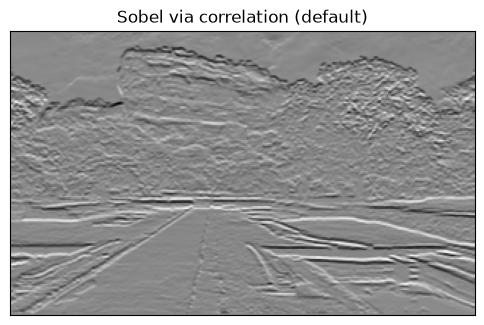

In [19]:
sobel_x = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]])

sobel_correlation = cv.filter2D(im, cv.CV_64F, sobel_x)

plt.figure(figsize=(6, 6))
plt.imshow(sobel_correlation, cmap='gray')
plt.title('Sobel via correlation (default)')
plt.xticks([]), plt.yticks([])
plt.show()


### Sobel via true convolution (flip the kernel first, then correlate)

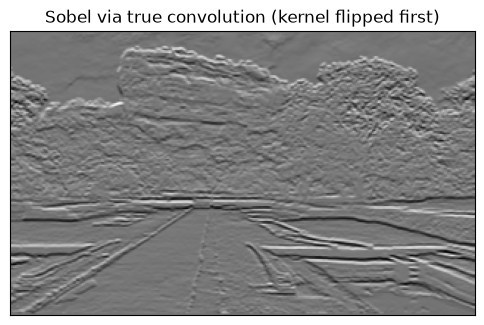

In [20]:
sobel_x_flipped = sobel_x[::-1, ::-1]
sobel_convolution = cv.filter2D(im, cv.CV_64F, sobel_x_flipped)

plt.figure(figsize=(6, 6))
plt.imshow(sobel_convolution, cmap='gray')
plt.title('Sobel via true convolution (kernel flipped first)')
plt.xticks([]), plt.yticks([])
plt.show()


### Side by side — look for the edge-polarity flip
A dark-to-bright edge in one result should read as bright-to-dark in the other.

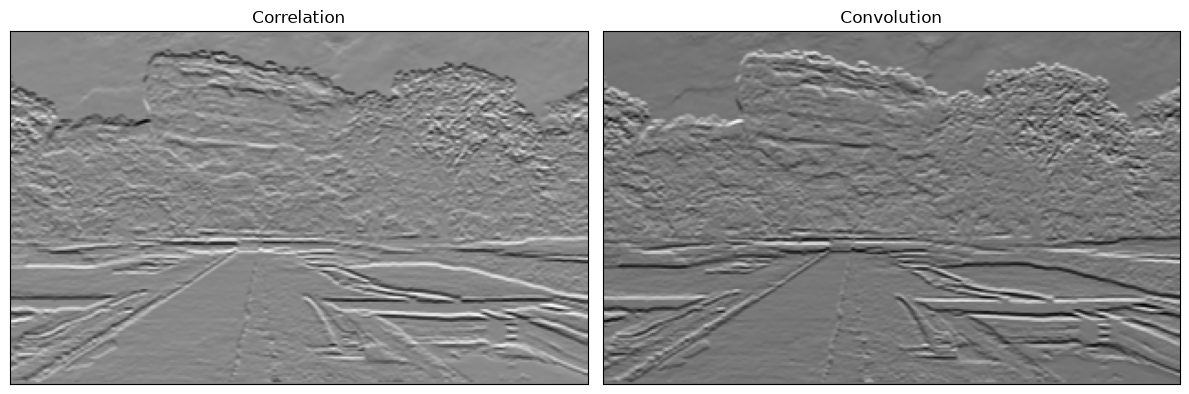

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex='all', sharey='all')
ax[0].imshow(sobel_correlation, cmap='gray')
ax[0].set_title('Correlation')
ax[1].imshow(sobel_convolution, cmap='gray')
ax[1].set_title('Convolution')
for a in ax:
    a.set_xticks([]), a.set_yticks([])
plt.tight_layout()
plt.show()


## 4. Real image, symmetric kernel (averaging)
Control case: a uniform 3x3 kernel is unchanged by a 180-degree flip, so correlation and convolution should be numerically identical here.

In [22]:
avg_kernel = np.ones((3, 3), np.float32) / 9

avg_correlation = cv.filter2D(im, cv.CV_32F, avg_kernel)
avg_kernel_flipped = avg_kernel[::-1, ::-1]
avg_convolution = cv.filter2D(im, cv.CV_32F, avg_kernel_flipped)

max_difference = np.abs(avg_correlation - avg_convolution).max()
print("max pixel difference:", max_difference)


max pixel difference: 0.0


If that printed `0.0` (or something vanishingly close due to float rounding), that's the expected result — proof that a symmetric kernel makes correlation and convolution interchangeable. If you ever see a large nonzero difference here after modifying the kernel, check whether you've made it asymmetric.